In [1]:
import PyUber
import pandas as pd

class PASDataEngine:
    def __init__(self, debug_flag=False, xeus_source='F32_PROD_XEUS',imo_source='D1D_PROD_XEUS_CENTRAL',imo_fab_list="'F32','F42','F12','F22','F52'"):
        self.debug_flag = debug_flag
        self.xeus_source = xeus_source
        self.imo_source = imo_source
        self.imo_fab_list = imo_fab_list
    
    def extract_lotflow(self, lot, npi, title, fab_prod, ret_prod):
        
        with PyUber.connect(datasource=self.xeus_source) as conn:
        
            query = f'''
                SELECT 
                        '{npi}' AS NPI
                        ,'{title}' AS TITLE
                        ,'{fab_prod}' AS FAB_PROD
                        ,'{ret_prod}' AS RET_PROD
                        ,flf.product AS product
                        ,flf.lot AS lot
                        ,flf.exec_seq AS exec_seq
                        ,flf.operation AS operation
                        ,flf.oper_short_desc AS oper_short_desc
                        ,o.oper_long_desc AS oper_long_desc
                        ,To_Char(flf.out_date,'yyyy-mm-dd hh24:mi:ss') AS out_date
                        ,flf.lot_priority_movein AS lot_priority_movein
                        ,o.area AS area
                        ,o.module AS module
                FROM 
                    F_Lot_Flow flf
                    CROSS JOIN F_Facility f
                    INNER JOIN F_Operation O ON o.operation=flf.operation AND o.facility = f.facility AND o.latest_version = 'Y'
                WHERE
                    flf.history_deleted_flag = 'N' 
                    AND flf.lot = '{lot}' 
            '''

            df = pd.read_sql(query, conn)

        return df
    
    def extract_reticleData(self, fab_prod, ret_name):
        
        with PyUber.connect(datasource= self.imo_source) as conn:

            # retProdList = retProds['RET_PROD'].unique()

            # Construct the WHERE clause dynamically
            # where_clause = ' OR '.join([f"z0.product LIKE '{ret_name}'" for value in retProdList])

            query = f'''
                SELECT 
                    z0.commonname AS common_name
                    ,z0.title AS title
                    ,'{fab_prod}' AS FAB_PROD
                    ,z0.product AS RET_PROD
                    ,z0.rev AS rev
                    ,z0.layer AS layer
                    ,z0.step AS step
                    ,z0.platetype AS plate_type
                    ,z0.tapeintrend AS tapein_trend
                    ,z0.itotrend AS ito_trend
                    ,To_Char(z0.itocommit,'yyyy-mm-dd hh24:mi:ss') AS ito_commit
                    ,z0.itostatus AS ito_status
                    ,z0.retfabrev AS ret_fabrev
                    ,z0.fab AS fab
                    ,z0.barcode AS barcode
                    ,z0.imotrend AS imo_trend
                    ,To_Char(z0.imocommit,'yyyy-mm-dd hh24:mi:ss') AS imo_commit
                    ,z0.imostatus AS imo_status
                    ,To_Char(z0.shipdate,'yyyy-mm-dd hh24:mi:ss') AS shipdate
                    ,z0.fabrequireddate AS fab_requireddate
                    ,z0.imodotprocess AS imo_dotprocess
                    ,z0.imoishot AS imo_ishot
                    ,z0.technology AS technology
                    ,z0.toengcontact AS to_engcontact
                    ,z0.dbnames AS dbnames
                    ,To_Char(z0.last_updated_timestamp,'yyyy-mm-dd hh24:mi:ss') AS last_updated_timestamp
                FROM 
                    F_IMO_TRIFECTA_DASHBOARD z0
                WHERE
                    1=1
                    --AND z0.last_updated_timestamp >= SYSDATE - 180 
                    AND z0.fab In ({self.imo_fab_list})     
                    AND (
                        z0.product LIKE '{ret_name}'
                    )
            '''
            df = pd.read_sql(query, conn)

            # df = pd.merge(df,retProds, on='RET_PROD', how='inner')
            # cursor.execute(query)

        # self.reticleData = df
        return df
    
    def extract_redwing(self, lot):
        with PyUber.connect(datasource= self.xeus_source) as conn:
        # cursor = conn.cursor()

            query = f'''
                SELECT DISTINCT
                    *
                FROM
                    F_RW_LOT_SCENARIO LS
                WHERE
                    LS.lot = '{lot}' 
                    AND LS.ADDED_BY <> 'ATC-AUTOLOAD'
                    AND LS.COMMITOUT is not null  
            '''
            df = pd.read_sql(query, conn)
        # cursor.execute(query)
        # self.redwing = df    
        return df
    


In [2]:
import pandas as pd

class Lot:
    def __init__(self, npi_name, lot_number, lot_title, fab_prod, ret_prod, commit, dataengine, debug_flag=False):
        """
        Initialize a Lot instance and extract necessary data.

        Parameters:
        - lot_number: The identifier for the lot.
        - lot_title: The title associated with the lot.
        - fab_prod: The fabrication product identifier.
        - ret_prod: The reticle product identifier.
        - dataengine: An instance of PASDataEngine for data extraction.
        """        
        self.npi_name = npi_name
        self.lot_number = lot_number
        self.lot_title = lot_title
        self.fab_prod = fab_prod
        self.ret_prod = ret_prod
        self.commit = commit
        self.debug_flag = debug_flag
        # self.dataengine = dataengine
        
        try:
            self.lot_flow_raw = dataengine.extract_lotflow(self.lot_number, self.npi_name, self.lot_title,self.fab_prod,self.ret_prod)
            self.lot_flow_raw = dataengine.extract_lotflow(self.lot_number, self.npi_name, self.lot_title,self.fab_prod,self.ret_prod)
            # (self, lot, npi, title, fab_prod, ret_prod)
            self.lot_redwing = dataengine.extract_redwing(self.lot_number)
            self.lot_flow = self.cleanup_LotFlow(self.lot_flow_raw)
            self.generate_plot_data()
        except Exception as e:
            print(f"Error extracting data for lot {self.lot_number}: {e}")
            self.lot_flow = None
            self.lot_redwing = None
            raise

        
        if self.debug_flag:
            self.lot_flow_raw.to_csv(f"debug/lot_flow_{lot_number}_raw.csv", index=False)
            self.lot_flow.to_csv(f"debug/lot_flow_{lot_number}.csv", index=False)
            self.lot_redwing.to_csv(f"debug/lot_redwing_{lot_number}_raw.csv", index=False)
    

    def get_layer(self, row):

        value = row['OPER_SHORT_DESC']

        if row['EXEC_SEQ'] == 1:
            return "START"
        if value[:1] == "Z":
            return "SHIP"
        
        cond_list = [' ','#',
                     'L58','L52','L46','L4','L5', #10nm conditions
                     'L8c','L8s','L8b','L86','L81','L8d','L8' #18A conditions
                     ] 

        for cond in cond_list:
            value = value.replace(cond,'')
            
        value = value[:3]

        if row['OPER_LONG_DESC'].find(value) == -1:
            if value[0]=='M':
                value = 'MT' + value[1]
            else:
                value = 'VA' + value[1]
            
        return value
    
    def check_act(self, value):
        if '*' in value:
            return 1
        else:
            return 0
                
    def cleanup_LotFlow(self,df):
        df = df.sort_values(by='EXEC_SEQ', ascending=True)
        df['ACTIVITY'] = df['OPER_SHORT_DESC'].apply(lambda x: self.check_act(x))
        df['CUM_ACTIVITY'] = df['ACTIVITY'].cumsum()


        df = df[(df['EXEC_SEQ']==1) |  
            (df['OPERATION']=='9812') |
            ((df['AREA']=='LITHO') & (
                # These are the modules for 18A
                (df['MODULE'] == "LI-SAVli") | 
                (df['MODULE'] == "LI-SAYli") | 
                (df['MODULE'] == "LI-SBHcu") | 
                (df['MODULE'] == "LI-SBLcu") | 
                (df['MODULE'] == "LI-SNEli") | 
                (df['MODULE'] == "LI-SNYli") |
                # These are the modules for 10nm
                (df['MODULE'] == "LI-BE-193") | 
                (df['MODULE'] == "LI-BE-SED") | 
                (df['MODULE'] == "LI-BE-WET") | 
                (df['MODULE'] == "LI-FE-193") | 
                (df['MODULE'] == "LI-PD-WET") |
                (df['MODULE'] == "LI-SSAFI-WET") |
                (df['MODULE'] == "LI-WET") | 
                (df['MODULE'] == "LI-FE-248")                
                )
            )
            ]

        df['LAYER'] = df.apply(lambda row: self.get_layer(row), axis=1)

        df['OUT_DATE'] = pd.to_datetime(df['OUT_DATE'], errors='coerce')     

        df.loc['0', 'OUT_DATE'] = df.loc[1,'OUT_DATE']

        return df
    
    def generate_plot_data(self):

        lot_flow = self.lot_flow
        commit = self.commit
        total_act = lot_flow['CUM_ACTIVITY'].max()
        days_remaining = (self.commit - pd.Timestamp.now()).days

        plot_data = lot_flow.groupby(['LAYER'])[['CUM_ACTIVITY','OUT_DATE','EXEC_SEQ']].max().reset_index()
        plot_data = plot_data.sort_values(by='EXEC_SEQ', ascending=True).reset_index(drop=True)

        plot_data['ACT'] = plot_data['CUM_ACTIVITY'].diff()

        plot_data['ACTUAL'] = plot_data['OUT_DATE']

        reverse_plot_data = plot_data[::-1]
        last_valid_index = reverse_plot_data['OUT_DATE'].first_valid_index()

        current_act = plot_data.loc[last_valid_index,'CUM_ACTIVITY'] if last_valid_index is not None else None

        # wt_req = (total_act - current_act)/days_remaining

        plan_release = plot_data.loc[1,'OUT_DATE']
        if pd.isna(plan_release):
            plan_release = pd.Timestamp.now()

        plan_first_act = plot_data.loc[1,'CUM_ACTIVITY']

        plan_total_days = (commit - plan_release).days
        plan_wt_req = (total_act - plan_first_act)/plan_total_days
        plan_base_start = plan_release + pd.Timedelta(days=plan_first_act/plan_wt_req)

        plot_data['TREND'] = plot_data['OUT_DATE']

        for idx in plot_data.index:
            plot_data.loc[idx,'PLAN'] = plan_base_start + pd.Timedelta(days=plot_data.loc[idx,'CUM_ACTIVITY']/plan_wt_req)

            if pd.isna(plot_data.loc[idx,'TREND']):
                plot_data.loc[idx,'TREND'] = plot_data.loc[idx-1,'TREND']+pd.Timedelta(days=plot_data.loc[idx,'ACT']/plan_wt_req)


        self.plot_data = plot_data.drop(columns=['EXEC_SEQ','CUM_ACTIVITY','OUT_DATE'])        
                


In [3]:
# from Class_PAS_Product import Product

# from Class_PAS_Lot import Lot
import pandas as pd
import numpy as np
# from PAS_Graph_Class import PASPlot

class Product:
    def __init__(self, npi_name, prod_details, dataengine, ret_version=None, lots=None, debug_flag=False):
        
        self.npi_name = npi_name
        self.fab_name = prod_details['FAB_PROD']
        self.ret_name = prod_details['RET_PROD']
        self.commit = prod_details['COMMIT']
        
        self.dataengine = dataengine
        self.debug_flag = debug_flag

        temp = None
        if ret_version is not None:
            temp = ret_version[ret_version['RET_PROD'] == self.ret_name]
            if temp.empty:
                temp = None
        self.ret_version = temp
            
        self.reticle_data = self.dataengine.extract_reticleData(self.fab_name, self.ret_name)
        if self.debug_flag: self.reticle_data.to_csv(f"debug/{self.fab_name}_reticle_data_raw.csv", index=False)
        self.RetData = self.reticle_manipulation()
        # self.RetPlotData = self.generate_ret_plot_data()
        if self.debug_flag: self.RetData.to_csv(f"debug/{self.fab_name}_reticle_data.csv", index=False)


        
        self.lots = []
        if lots:
            for lot_number, lot_title in lots.items():
                self.add_lot(lot_number, lot_title)

    def add_lot(self, lot_number, lot_title):
        lot = Lot(self.npi_name, lot_number, lot_title, self.fab_name, self.ret_name, self.commit, self.dataengine, self.debug_flag)
        self.lots.append(lot)

        if len(self.lots) == 1:
            self.base_flow = self.baseline_flow(lot.lot_flow)
            # self.RetPlotData = self.RetDataOrder()

    def RetDataOrder(self):
        df = pd.merge(self.RetPlotData, self.base_flow[['LAYER','EXEC_SEQ']], how='left', on=['LAYER'])
        df = df.sort_values(by='EXEC_SEQ', ascending=True).reset_index()
        return df

    def cleanRetCol(self, dt):
        try:
            dt = pd.to_datetime(dt)
            return dt
        except ValueError:
            dt = dt.str.replace('~','')
            dt = pd.to_datetime(dt)
            return dt

    def convert_to_days(self, col,min_val):
        col = col - min_val
        col = col.apply(lambda x: x.days if x>pd.Timedelta(days=0) else 0)
        return col
    
    def cleanupCommit(self, row):
        cutoff_date = pd.Timestamp.now() - pd.Timedelta(days=180)
        
        if row['IMO_TREND'] < cutoff_date:
            return row['IMO_COMMIT']
        else:
            return row['IMO_TREND']


    def reticle_version_handling(self, df):
        """
        Uses the reticle data version input to overide and select specific reticles to use in tracking
        """
        df['VER'] = df['RET_PROD'].str[:3]
        merged_data = df.merge(self.ret_version, how='left', on=['RET_PROD', 'LAYER'])
        df = merged_data[(merged_data['VER'] == merged_data['VERSION']) | merged_data['VERSION'].isna()]
        df.drop(columns=['VER','VERSION'], inplace=True)
        
        return df

    def reticle_manipulation(self):
        """
        Uses the reticle data version input to overide and select specific reticles to use in tracking
        """
        RetData = self.reticle_data.copy()

        col_list =['TAPEIN_TREND','ITO_TREND','ITO_COMMIT','IMO_TREND','IMO_COMMIT','SHIPDATE','FAB_REQUIREDDATE']
        for col in col_list:
            RetData[col] = self.cleanRetCol(RetData[col])

        if self.ret_version is not None:
            RetData = self.reticle_version_handling(RetData)

        cutoff_date = pd.Timestamp.now() - pd.Timedelta(days=180)
        RetData = RetData[RetData['IMO_COMMIT']>=cutoff_date]
        RetData['IMO_TREND'] = RetData.apply(lambda row: self.cleanupCommit(row), axis =1)

        indexNames = RetData[RetData['IMO_STATUS']=='Rejected'].index
        RetData.drop(indexNames, inplace=True)

        indexNames = RetData[RetData['IMO_STATUS']=='Processing - Hold With Waiver'].index
        RetData.drop(indexNames, inplace=True)

        RetData['RetRev'] = RetData['TITLE'].str.slice(0, 3) 
        RetData['RetNum'] = RetData['TITLE'].str[3:4]

        # Filter out rows where IMO_STATUS is not 'Shipped' if there is at least one 'Shipped' status for the same LAYER
        shipped_data = RetData[RetData['IMO_STATUS'] == 'Shipped'][['FAB_PROD', 'LAYER']].drop_duplicates()
        RetData = RetData[~((RetData['IMO_STATUS'] != 'Shipped') & (RetData['LAYER'].isin(shipped_data['LAYER'])) & (RetData['RET_PROD'].isin(shipped_data['FAB_PROD'])))]

        # Filter out rows where SHIP is not the earliest for the same LAYER
        RetData = RetData[~((RetData['SHIPDATE'].isna()) & (RetData['IMO_COMMIT'] < pd.Timestamp.now()))]

        RetData = pd.pivot_table(RetData,index=['LAYER'], values=['TAPEIN_TREND','ITO_TREND','FAB_REQUIREDDATE','IMO_TREND','SHIPDATE'], aggfunc=np.min).reset_index()
        RetData['TI'] = RetData['TAPEIN_TREND']
        RetData['TO'] = RetData['ITO_TREND']# - RetData['TI']
        RetData['SHIP'] = RetData['SHIPDATE']# - RetData['TI']
        RetData['ESD'] = RetData['IMO_TREND']# - RetData['TI']
        RetData['FRD'] = RetData['FAB_REQUIREDDATE']# - RetData['TI']

        RetData.loc[RetData['SHIP'].notna(), 'ESD'] = pd.NaT

        #RetData['SHIP'] = RetData['SHIP'].fillna(pd.Timedelta(days=0))
        #RetData['ESD'] = RetData['ESD'].fillna(pd.Timedelta(days=0))
        RetData = RetData[['LAYER', 'TI', 'TO', 'ESD', 'SHIP', 'FRD']]   

        return RetData     
    
    def baseline_flow(self,lot_flow):
        self.days_remaining = (self.commit - pd.Timestamp.now()).days

        order_flow = lot_flow.pivot_table(index=['NPI','FAB_PROD','LAYER'],values=['EXEC_SEQ','CUM_ACTIVITY'],aggfunc='min')
        order_flow = order_flow.sort_values(by='EXEC_SEQ', ascending=True).reset_index()

        self.total_act = order_flow['CUM_ACTIVITY'].max()

        order_flow['ACT'] = order_flow['CUM_ACTIVITY'].diff()

        return order_flow


    def build_plot_data(self):
          
        base_flow = self.base_flow.copy()
        ReticleData = self.RetData.copy()
        plotdata = pd.merge(base_flow[['LAYER','EXEC_SEQ']], ReticleData, how='left', on=['LAYER'])

        # plotdata['TI'] = plotdata['TI'].fillna(plotdata['TI'].min())
        bar_columns = ['TI', 'TO', 'ESD', 'SHIP', 'FRD']
        # for col in columns_to_fill:
        #     plotdata[col] = plotdata[col].fillna(0)  # Fill NaN with 0
        #     plotdata[col] = pd.to_timedelta(plotdata[col], unit='D')  # Convert to Timedelta



        for n in range(len(self.lots)):
            lot_plot_data = self.lots[n].plot_data.copy()
            lot_title = self.lots[n].lot_title
            
            lot_plot_data['NPI PLAN'] = lot_plot_data['PLAN']
            lot_plot_data[f'{lot_title} TREND'] = lot_plot_data['TREND']
            lot_plot_data[f'{lot_title} ACTUAL'] = lot_plot_data['ACTUAL']

            lot_plot_data = lot_plot_data[['LAYER', 'NPI PLAN', f'{lot_title} TREND', f'{lot_title} ACTUAL']]

            if n > 0:
                lot_plot_data = lot_plot_data[['LAYER', f'{lot_title} TREND', f'{lot_title} ACTUAL']]
                

            plotdata = pd.merge(plotdata, lot_plot_data, how='left', on=['LAYER'])
        
        trend_columns = [col for col in plotdata.columns if col.endswith('TREND')]
        trend_columns
        max_line = max(plotdata[trend_columns].max())
        min_line = min(plotdata[trend_columns].min())

        min_TI = plotdata['TI'].min()

        timeDelta = min_line - min_TI

        # Normalize dates to round down to the nearest day
        ymin_date = (min_line - pd.Timedelta(days=30)).normalize()
        ymax_date = (max_line + pd.Timedelta(days=7)).normalize()

        # Calculate the difference in days
        difference_days = (ymax_date - ymin_date).days
        print(f"Difference in days: {difference_days} days")

        # Round up the difference to the nearest multiple of 7
        rounded_difference = np.ceil(difference_days / 7) * 7
        print(f"Rounded difference: {rounded_difference} days")

        ymax_date = ymin_date + pd.Timedelta(days=rounded_difference)
        ymin_val = 0
        ymax_val = rounded_difference


        print(f"ymin_date: {ymin_date}")
        print(f'ymin_val: {ymin_val}')
        print(f"ymax_date: {ymax_date}")
        print(f'ymax_val: {ymax_val}')
        # ymin_days = 0
        # ymin_days = ymax
        for col in bar_columns:
            plotdata[col] = self.convert_to_days(plotdata[col],ymin_date)

        self.plot_data = plotdata.copy()
        self.ymin_date = ymin_date
        self.ymax_date = ymax_date
        self.ymin_val = ymin_val
        self.ymax_val = ymax_val


    def debug_dump(self):
        """
        Dump debug data to CSV files.
        """
        self.reticle_data.to_csv(f"debug/{self.fab_name}_reticle_data.csv", index=False)
        for lot in self.lots:
            lot.lot_flow.to_csv(f"debug/{lot.lot_number}_lot_flow.csv", index=False)
            lot.plot_data.to_csv(f"debug/{lot.lot_number}_plot_data.csv", index=False)
          

In [4]:
from Class_PAS_Data_Extract import PASDataEngine


In [5]:
import pandas as pd

In [6]:
def read_excel_to_dataframe(file_path, sheet_name, halt_on_error=True):
    """
    Reads a specific worksheet from an Excel file into a Pandas DataFrame.

    Parameters:
    - file_path (str): The path to the Excel file.
    - sheet_name (str or int): The name or index of the worksheet to load.
    - halt_on_error (bool): Flag indicating whether to halt execution on error.
                            If False, the function will return None on error.

    Returns:
    - DataFrame or None: The DataFrame if successful, or None if an error occurs and halt_on_error is False.
    """
    try:
        # Attempt to read the specified worksheet into a DataFrame
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        return df
    except Exception as e:
        # Handle the error based on the halt_on_error flag
        if halt_on_error:
            print(f"Error reading {file_path}, sheet {sheet_name}: {e}")
            raise  # Re-raise the exception to halt execution
        else:
            print(f"Error reading {file_path}, sheet {sheet_name}: {e}. Returning None.")
            return None



In [7]:
config_file = r'\\azshfs.intel.com\AZAnalysis$\1272_MAODATA\Config\PDE\dagarcia\PAS_CONFIG\P1278_Config.xlsx'

pas_config = read_excel_to_dataframe(config_file, 'PlotConfig', halt_on_error=True)
email_config = read_excel_to_dataframe(config_file, 'EmailConfig', halt_on_error=True)
reticle_config = read_excel_to_dataframe(config_file, 'ReticleConfig', halt_on_error=False)

In [8]:
if  pas_config is not None:
    unique_combos = pas_config.groupby(['PRODUCT', 'FAB_PROD', 'RET_PROD'])['COMMIT'].max().reset_index()

    products = unique_combos.set_index('PRODUCT').to_dict(orient='index')
    
    for product, details in products.items():
        print(f"Processing Product: {product}")
        print(f"FAB_PROD: {details['FAB_PROD']}, RET_PROD: {details['RET_PROD']}, COMMIT: {details['COMMIT']}")



Processing Product: 1x278D
FAB_PROD: 1L278VD, RET_PROD: 1X278D, COMMIT: 2025-08-04 00:00:00
Processing Product: 8PXSCB
FAB_PROD: 8PXSCVB, RET_PROD: 8PXSCB, COMMIT: 2025-08-14 00:00:00


In [9]:
products['8PXSCB']

{'FAB_PROD': '8PXSCVB',
 'RET_PROD': '8PXSCB',
 'COMMIT': Timestamp('2025-08-14 00:00:00')}

In [10]:
dataengine = PASDataEngine()

In [11]:

prod = Product('8PXSCB', products['8PXSCB'],  dataengine, ret_version=reticle_config, lots=None, debug_flag=False)

d:\Python\PAS_Graphs\Class_PAS_Data_Extract.py:91: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\dagarcia\AppData\Local\Temp\ipykernel_14516\3824365669.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['VER','VERSION'], inplace=True)
C:\Users\dagarcia\AppData\Local\Temp\ipykernel_14516\3824365669.py:119: FutureWarning: The provided callable <function min at 0x000001CE79E78D60> is currently using DataFrameGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  RetData = pd.pivot_table(RetData,index=['L

In [12]:
prod.add_lot('L5139670', 'Lead Lot')
prod.add_lot('L5139630', 'Scout 1')
prod.add_lot('L5139640', 'Scout 2')

d:\Python\PAS_Graphs\Class_PAS_Data_Extract.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
d:\Python\PAS_Graphs\Class_PAS_Data_Extract.py:113: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Error extracting data for lot L5139670: 1


KeyError: 1

In [13]:
prod.build_plot_data()


Difference in days: 195 days
Rounded difference: 196.0 days
ymin_date: 2025-02-26 00:00:00
ymin_val: 0
ymax_date: 2025-09-10 00:00:00
ymax_val: 196.0


In [17]:

plotdata = prod.plot_data
ymin_date = prod.ymin_date
ymax_date = prod.ymax_date
ymin_val = prod.ymin_val
ymax_val = prod.ymax_val

C:\Users\dagarcia\AppData\Local\Temp\ipykernel_15124\2060182472.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(plotdata['LAYER'], rotation=90, fontsize=8)


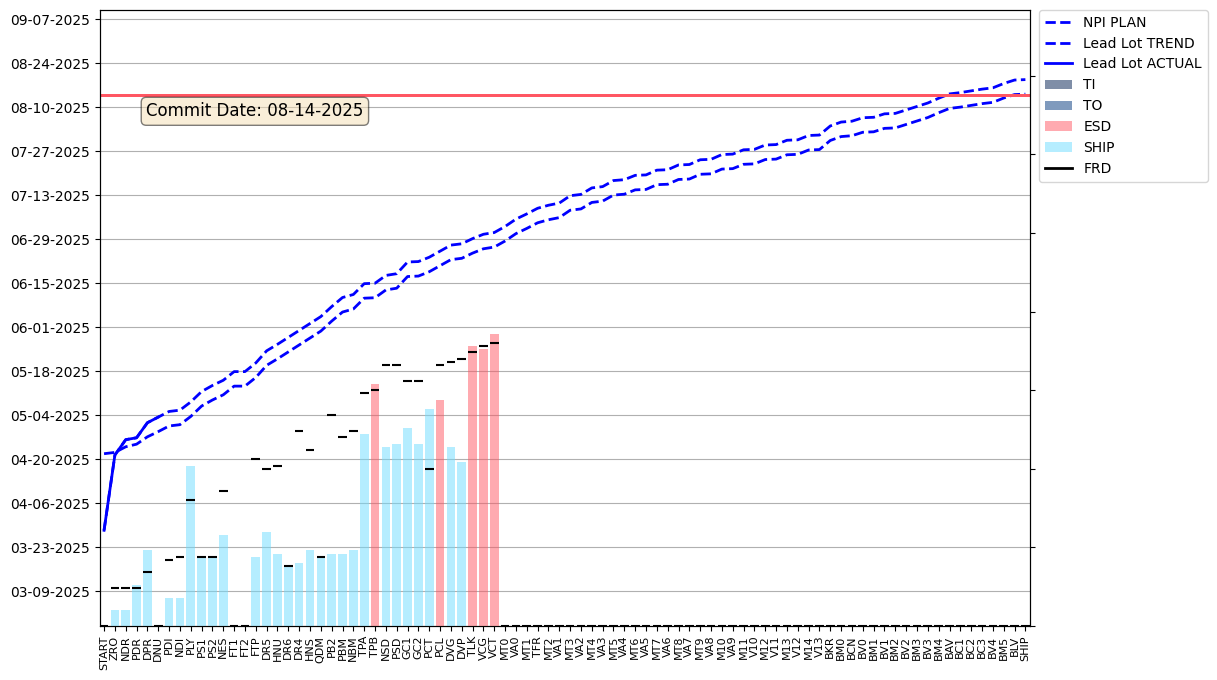

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D



commit_date = prod.commit
fig, ax1 = plt.subplots(figsize=(12, 8))

ax1.plot(plotdata['LAYER'], plotdata['NPI PLAN'],color='blue', label='NPI PLAN', linewidth=2, linestyle='--')

ax1.plot(plotdata['LAYER'], plotdata['Lead Lot TREND'],color='blue', label='Lead Lot TREND', linewidth=2, linestyle='--')  
ax1.plot(plotdata['LAYER'], plotdata['Lead Lot ACTUAL'],color='blue', label='Lead Lot ACTUAL', linewidth=2)
ax2 = ax1.twinx()

# bottom = plotdata['BaseLine']

bar_colors = ['#001E50','#00377C', '#FF5662', '#6DDCFF', '#A0EBFF']
bar_columns = ['TI', 'TO', 'ESD', 'SHIP']

ax1.axhline(y=commit_date, color='#FF5662', linestyle='-', linewidth=2)

for idx, bar in enumerate(bar_columns):
    if idx==0:
        ax2.bar(plotdata['LAYER'], plotdata[bar], label=bar, color=bar_colors[idx], alpha=0.5)
    else:
        ax2.bar(plotdata['LAYER'], plotdata[bar], bottom=plotdata[bar_columns[idx-1]], label=bar, color=bar_colors[idx], alpha=0.5)


for bar,frd in zip(plt.gca().patches,plotdata['FRD']):
    x = bar.get_x() + bar.get_width() / 2
    ax2.hlines(frd, x-bar.get_width()/2, x+bar.get_width()/2, color='black')

ax1.set_ylim(ymin_date, ymax_date)
ax2.set_ylim(ymin_val, ymax_val)

fig.patch.set_facecolor('white')

# Add a text box in the upper left
textstr = f'Commit Date: {commit_date.strftime("%m-%d-%Y")}'
# textstr += f'\nTrend Date: {Trend_Date.strftime("%m-%d-%Y")}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax1.text(0.05, 0.85, textstr, transform=ax1.transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='left', bbox=props)

# Set the background color of the axes (the plot area) to white
ax1.set_facecolor('white')
ax2.set_facecolor('white')

ax1.set_xticklabels(plotdata['LAYER'], rotation=90, fontsize=8)
ax2.set_yticklabels([])
ax1.margins(x=0)
ax1.yaxis.grid(True)
ax1.yaxis.set_major_locator(mdates.DayLocator(interval=14)) 
ax1.yaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%Y'))
ax1.axhline(y=commit_date, color='#FF5662', linestyle='-', linewidth=2)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
frd_line = Line2D([0], [0], linestyle='-', color='black', linewidth=2, label='FRD')

handles = handles1 + handles2 + [frd_line]
labels = labels1 + labels2 + ['FRD']
plt.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.01,1),borderaxespad=0.)